## Section 0: Auto-download dataset if missing

In [2]:
import os

DATA_DIR = "/content/data/MSRA10K_Imgs_GT/Imgs"

# Step 1: Check if dataset exists
if not os.path.exists(DATA_DIR):
    print("Dataset not found → downloading...")

    # Install kaggle if needed
    !pip install -q kaggle

    # Download dataset
    !kaggle datasets download -d evvalaycan/saliency-object-segmentation-msra10k

    # Unzip
    !unzip -q saliency-object-segmentation-msra10k.zip -d /content/data

else:
    print("Dataset already exists.")

# Step 2: Verify structure
print("\nVerifying dataset structure...")

for root, dirs, files in os.walk("/content/data"):
    print(root, len(files))

Dataset not found → downloading...
Dataset URL: https://www.kaggle.com/datasets/evvalaycan/saliency-object-segmentation-msra10k
License(s): unknown
100% 198M/198M [00:02<00:00, 83.6MB/s]


Verifying dataset structure...
/content/data 1
/content/data/MSRA10K_Imgs_GT 0
/content/data/MSRA10K_Imgs_GT/Imgs 20000


## Section 1: Project setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/SOD_Project
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SOD_Project
checkpoints	     evaluate.py			       sod_model.py
data_loader.py	     __pycache__			       train.py
demo_notebook.ipynb  README.md
dog.jpg		     saliency-object-segmentation-msra10k.zip


## Section 2: Dataset path check

In [4]:
# ============================================
# Expected:
# Dataset exists: True
# Images: 10000
# Masks: 10000
# ============================================
import os

print("Dataset exists:", os.path.exists(DATA_DIR))

if os.path.exists(DATA_DIR):
    files = os.listdir(DATA_DIR)
    image_files = [f for f in files if f.endswith(".jpg")]
    mask_files = [f for f in files if f.endswith(".png")]

    print("Images:", len(image_files))
    print("Masks:", len(mask_files))
else:
    print("Dataset not found. You need to download/unzip it again into /content/data/")

Dataset exists: True
Images: 10000
Masks: 10000


## Section 3: Create/load DataLoaders

In [5]:
from data_loader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(
    DATA_DIR,
    img_size=128,
    batch_size=16
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 438
Validation batches: 94
Test batches: 94


## Section 4: Test one batch

In [6]:
images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Image min/max:", images.min().item(), images.max().item())
print("Mask min/max:", masks.min().item(), masks.max().item())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([16, 3, 128, 128])
Mask batch shape: torch.Size([16, 1, 128, 128])
Image min/max: 0.0 1.0
Mask min/max: 0.0 1.0


## Section 5: Visualize Augmented Training Samples

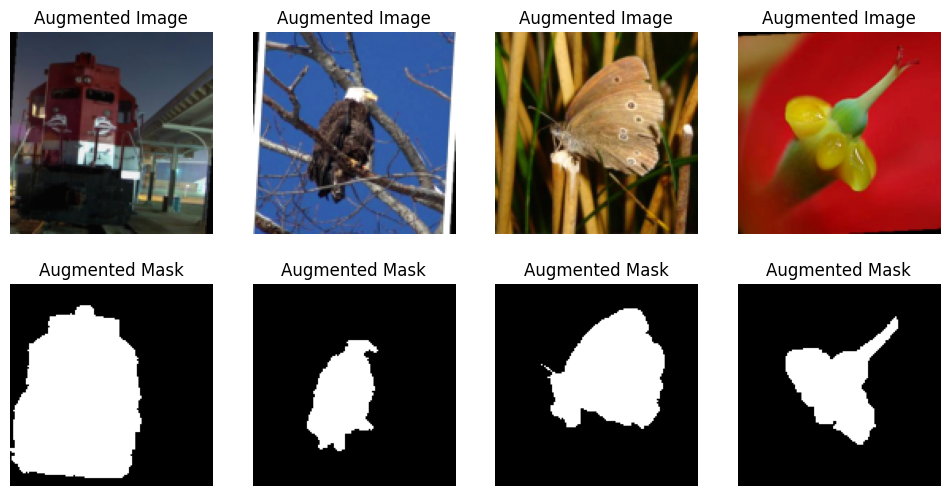

In [7]:
import matplotlib.pyplot as plt

images, masks = next(iter(train_loader))

plt.figure(figsize=(12, 6))

for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title("Augmented Image")
    plt.axis("off")

    plt.subplot(2, 4, i + 5)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Augmented Mask")
    plt.axis("off")

plt.show()

## Section 6: Visualization sanity check

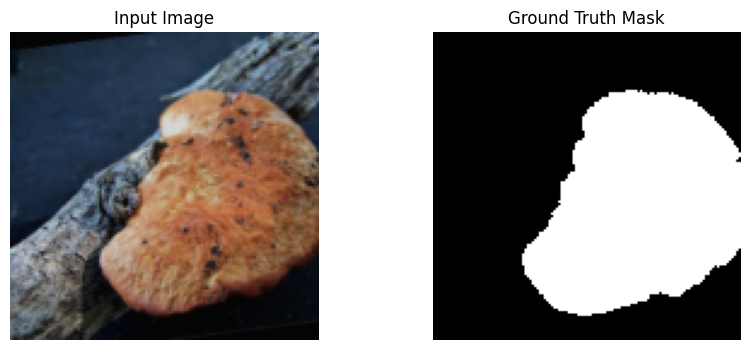

In [8]:
import matplotlib.pyplot as plt

images, masks = next(iter(train_loader))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(masks[0][0], cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

## Section 7: Test SOD Model

In [9]:
import torch
from sod_model import BaselineSODModel, ImprovedSODModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

baseline_model = BaselineSODModel().to(device)
improved_model = ImprovedSODModel().to(device)

sample_images, sample_masks = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    baseline_output = baseline_model(sample_images)
    improved_output = improved_model(sample_images)

print("Baseline output shape:", baseline_output.shape)
print("Improved output shape:", improved_output.shape)
print("Baseline output min/max:", baseline_output.min().item(), baseline_output.max().item())
print("Improved output min/max:", improved_output.min().item(), improved_output.max().item())

Device: cpu
Baseline output shape: torch.Size([16, 1, 128, 128])
Improved output shape: torch.Size([16, 1, 128, 128])
Baseline output min/max: 0.4669087529182434 0.47217807173728943
Improved output min/max: 0.02390006184577942 0.8088342547416687


## Section 8: Train Baseline Model

Note: If a previous checkpoint already exists and all 20 epochs were completed, the resume logic will load the checkpoint and finish immediately. This means training was already completed successfully.

In [10]:
import torch
import torch.optim as optim

from sod_model import BaselineSODModel
from train import train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

baseline_model = BaselineSODModel().to(device)

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=1e-3
)

train_losses, val_losses = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=20,
    checkpoint_dir="/content/drive/MyDrive/SOD_Project/checkpoints",
    model_name="baseline_20ep",
    resume=True
)

Device: cpu
Checkpoint found: /content/drive/MyDrive/SOD_Project/checkpoints/baseline_20ep_last_checkpoint.pth
Loading checkpoint and resuming training...
Resumed training from epoch 21.
Best validation loss so far: 0.7885
Training finished.


## Section 9: Evaluate Baseline Model

In [11]:
import torch
from sod_model import BaselineSODModel
from evaluate import evaluate_model, visualize_predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
model = BaselineSODModel().to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/SOD_Project/checkpoints/baseline_20ep_best.pth",
    map_location=device
    )
)

metrics = evaluate_model(model, test_loader, device)

print("Evaluation Results:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

Evaluation Results:
IoU: 0.6004
Precision: 0.7186
Recall: 0.8018
F1: 0.7247


## Section 9.1: Visualize Baseline Predictions

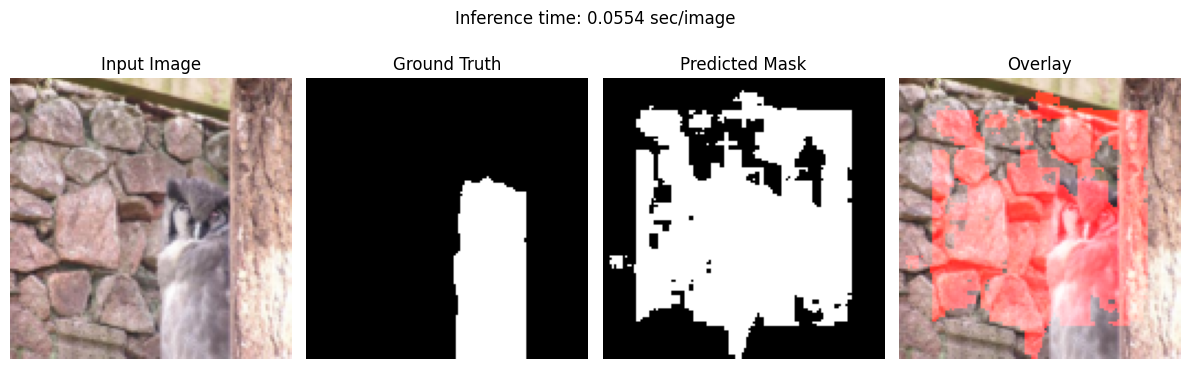

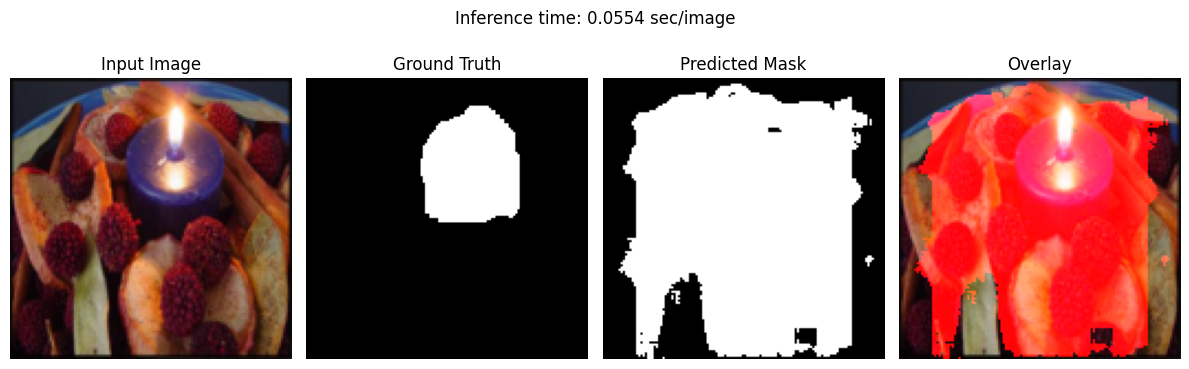

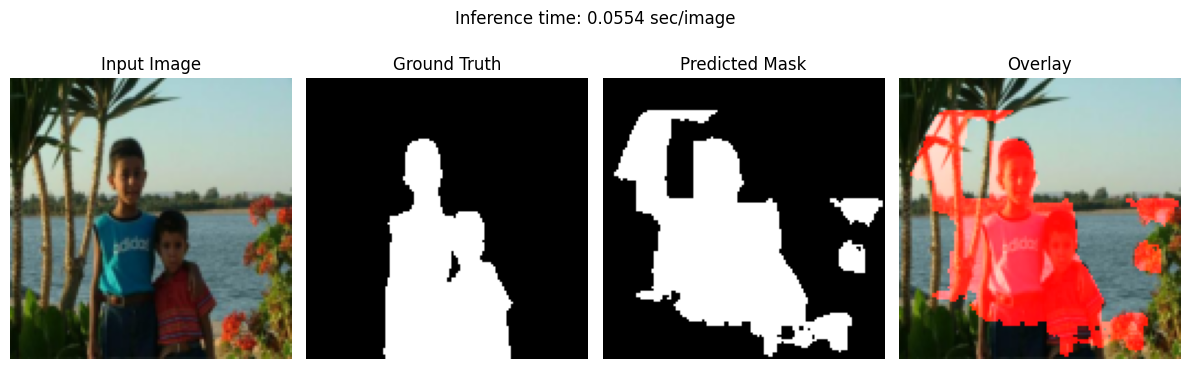

In [12]:
visualize_predictions(model, test_loader, device, num_samples=3)

## Section 10: Train Improved Model With Augmentation

Note: If a previous checkpoint already exists and all 20 epochs were completed, the resume logic will load the checkpoint and finish immediately. This means training was already completed successfully.

In [13]:
import torch
import torch.optim as optim

from sod_model import ImprovedSODModel
from train import train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

improved_aug_model = ImprovedSODModel().to(device)

optimizer = optim.Adam(
    improved_aug_model.parameters(),
    lr=1e-3
)

train_losses_aug, val_losses_aug = train_model(
    model=improved_aug_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    epochs=20,
    checkpoint_dir="/content/drive/MyDrive/SOD_Project/checkpoints",
    model_name="improved_augmented_20ep",
    resume=True
)

Device: cpu
Checkpoint found: /content/drive/MyDrive/SOD_Project/checkpoints/improved_augmented_20ep_last_checkpoint.pth
Loading checkpoint and resuming training...
Resumed training from epoch 21.
Best validation loss so far: 0.5201
Training finished.


## Section 11: Evaluate Improved Model With Augmentation

In [14]:

import torch

from sod_model import ImprovedSODModel
from evaluate import evaluate_model, visualize_predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_aug = ImprovedSODModel().to(device)

model_aug.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/SOD_Project/checkpoints/improved_augmented_20ep_best.pth",
        map_location=device
    )
)

metrics_aug = evaluate_model(model_aug, test_loader, device)

print("Improved Model With Augmentation Results:")
for k, v in metrics_aug.items():
    print(f"{k}: {v:.4f}")

Improved Model With Augmentation Results:
IoU: 0.7270
Precision: 0.8068
Recall: 0.8851
F1: 0.8256


## Section 12: Visualize Improved Model Predictions

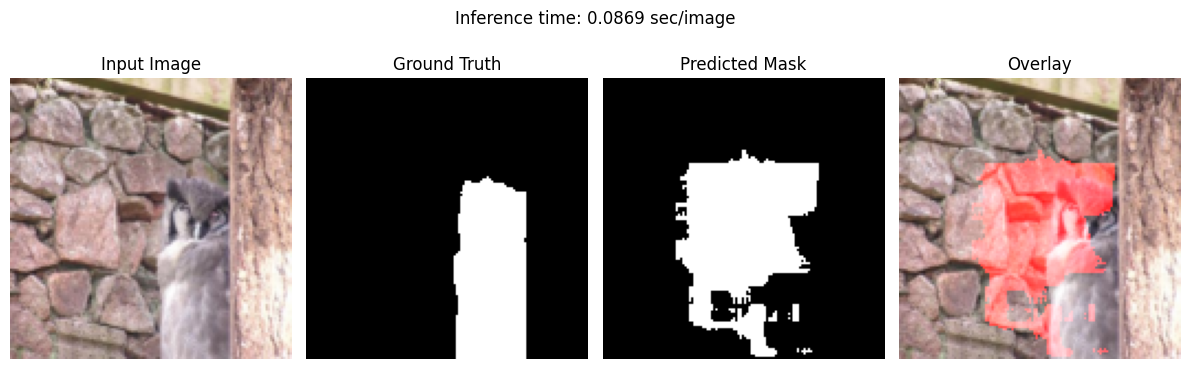

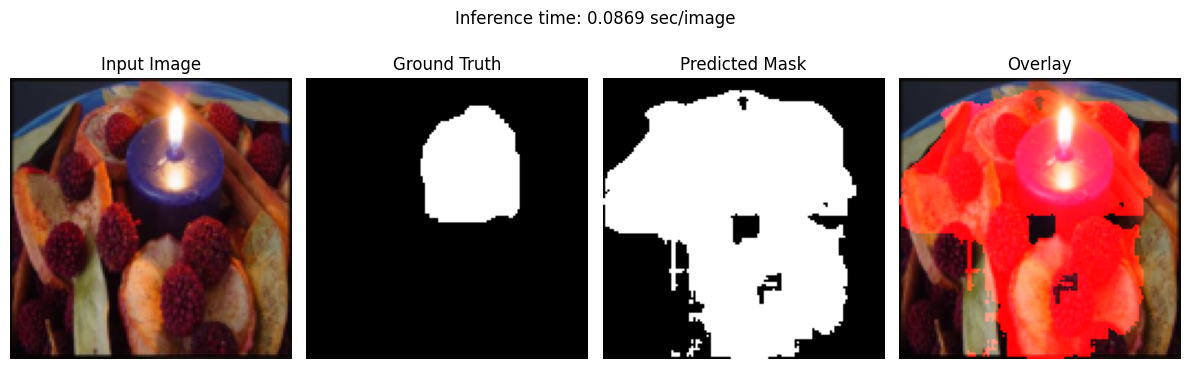

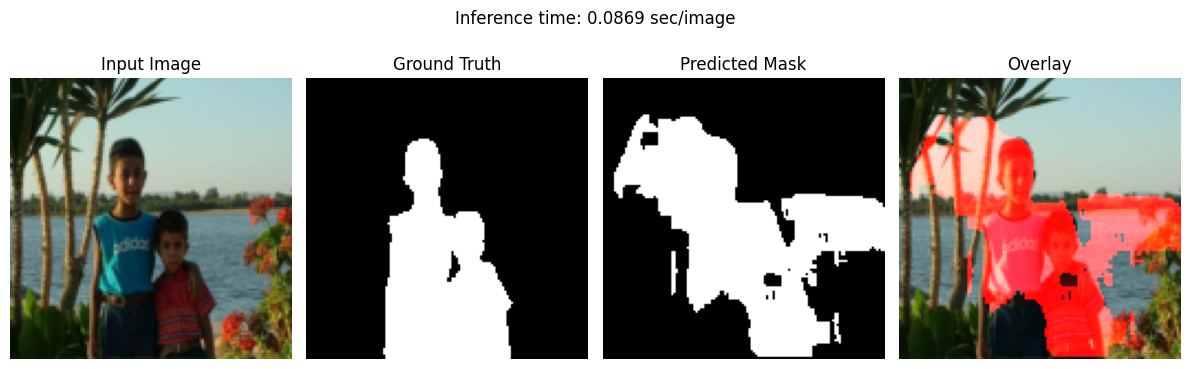

In [15]:
visualize_predictions(model_aug, test_loader, device, num_samples=3)

## Section 13: Final Metrics Comparison

In [16]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Baseline": metrics,
    "Improved + Augmentation": metrics_aug
}).T

comparison_df

,IoU,Precision,Recall,F1
Baseline,0.600420,0.718640,0.801769,0.724701
Improved + Augmentation,0.727032,0.806792,0.885093,0.825630


## Section 14: Plot Training Curves

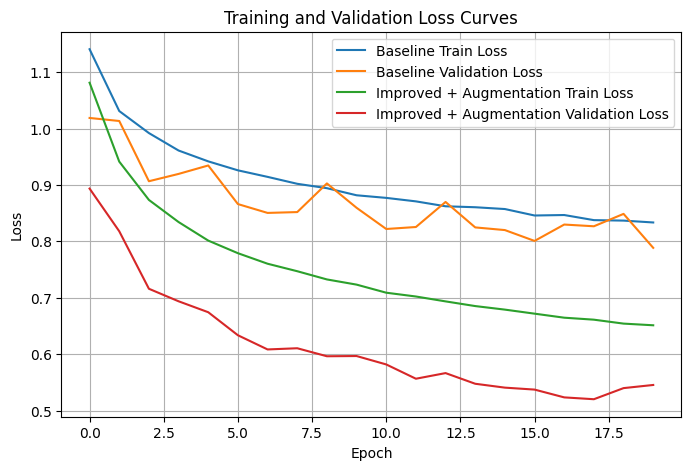

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Baseline model
plt.plot(train_losses, label="Baseline Train Loss")
plt.plot(val_losses, label="Baseline Validation Loss")

# Improved model with augmentation
plt.plot(train_losses_aug, label="Improved + Augmentation Train Loss")
plt.plot(val_losses_aug, label="Improved + Augmentation Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

## Demo: Upload Any Image and Predict Saliency Mask

This demo allows the user to upload any image and run inference using the trained improved SOD model.

The demo shows:

- the input image,
- the predicted saliency mask,
- the overlay between the image and the predicted mask,
- the inference time per image.

For the live demo, the model is not retrained. Instead, the best trained checkpoint is loaded and used directly for prediction.

## Loading the model

In [18]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the improved model
model_aug = ImprovedSODModel().to(device)

# Load the best improved checkpoint
checkpoint_path = "/content/drive/MyDrive/SOD_Project/checkpoints/improved_augmented_20ep_best.pth"

model_aug.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model_aug.eval()

print("Improved model loaded successfully.")

Improved model loaded successfully.


Saving dog.jpg to dog.jpg


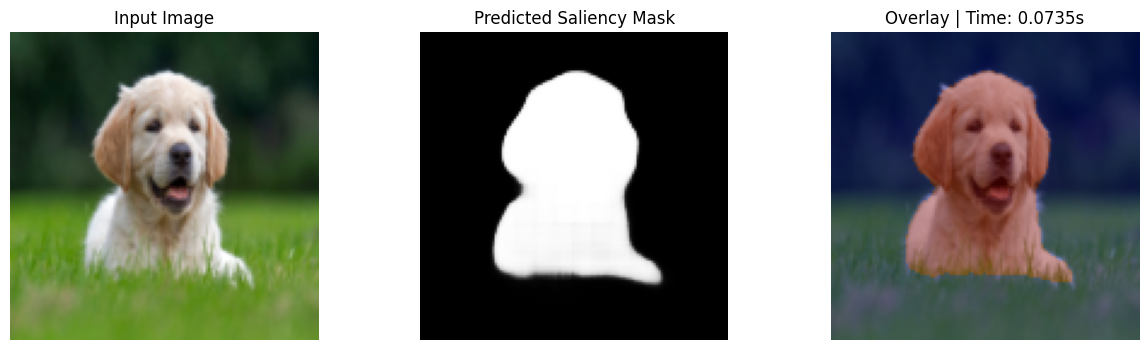

In [19]:

from google.colab import files
from PIL import Image
import time
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# Upload image from local computer
uploaded = files.upload()

# Call the improved model
model_aug.eval()

for filename in uploaded.keys():
    # Load uploaded image
    image = Image.open(filename).convert("RGB")

    # Resize image to match model input size
    image_resized = TF.resize(image, (128, 128))

    # Convert image to tensor and add batch dimension
    image_tensor = TF.to_tensor(image_resized).unsqueeze(0).to(device)

    # Measure inference time
    start_time = time.time()

    with torch.no_grad():
        predicted_mask = model_aug(image_tensor)

    inference_time = time.time() - start_time

    # Prepare mask for visualization
    predicted_mask = predicted_mask.squeeze().cpu()
    binary_mask = (predicted_mask > 0.5).float()

    # Display results
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_resized)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("Predicted Saliency Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(image_resized)
    plt.imshow(binary_mask, cmap="jet", alpha=0.4)
    plt.title(f"Overlay | Time: {inference_time:.4f}s")
    plt.axis("off")

    plt.show()

## Section 16: Conclusion

The implemented Salient Object Detection system successfully detects visually important regions from input images using a CNN encoder-decoder architecture trained from scratch.

The improved model achieved better results than the baseline model across all evaluation metrics:

- IoU improved from 0.6004 to 0.7270.
- Precision improved from 0.7186 to 0.8068.
- Recall improved from 0.8018 to 0.8851.
- F1-score improved from 0.7247 to 0.8256.

The improvements came from using a deeper architecture, batch normalization, dropout, and stronger data augmentation. The final demo also allows any image to be uploaded and processed, showing the predicted saliency mask, overlay visualization, and inference time.